**Name:** Zach Balgut Tan, zb2362

**Course:** Applied Machine Learning COMS4995_032

**Assignment:** [A2] From Single Models To Ensemble Models

# Introduction

The goal of this assignment is to explore the power of Boosting methods. We will compare performance of a single decision tree model and investigate how Boosting approaches improve generalization by correcting residual errors in sequential learners.

The dataset used is a Bank Marketing Dataset, with the goal of predicting whether a customer will subscribe to a term deposit based on demographic and campaign features.

Link to the dataset: https://uci.edu/dataset/222/bank+marketing

# Importing Library and Data

## Importing Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Importing Data

In [2]:
# Define column names based on the dataset description
column_names = [
    "age", "job", "marital_status", "education", "default",
    "housing", "loan", "contact", "month", "day_of_week", "duration",
    "campaign", "pdays", "previous", "poutcome", "emp_var_rate",
    "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed", "y"
]

# Load the dataset, specifying the column names and handling missing values
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/AML Assignment 2/bank-additional-full.csv',
    sep=';', # Specify the semicolon as the delimiter
    header=0, # Use the second row as the header (0-indexed)
    names=column_names, # Assign the predefined column names
    na_values='?' # Treat '?' as missing values
)

In [3]:
print(df.head())

display(df.info())

   age        job marital_status    education  default housing loan  \
0   56  housemaid        married     basic.4y       no      no   no   
1   57   services        married  high.school  unknown      no   no   
2   37   services        married  high.school       no     yes   no   
3   40     admin.        married     basic.6y       no      no   no   
4   56   services        married  high.school       no      no  yes   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  telephone   may         mon  ...         1    999         0  nonexistent   
1  telephone   may         mon  ...         1    999         0  nonexistent   
2  telephone   may         mon  ...         1    999         0  nonexistent   
3  telephone   may         mon  ...         1    999         0  nonexistent   
4  telephone   may         mon  ...         1    999         0  nonexistent   

  emp_var_rate  cons_price_idx  cons_conf_idx  euribor3m  nr_employed   y  
0          1.1        

None

## Description of Features in the Dataset

Numerical Features:
* (1)age: age of client
* (11)duration: last contact duration in seconds
* (12)campaign: number of contacts performed during this campaign and for this client
* (13)pdays: number of days that passed by after the client was last contacted from a previous campaign
* (14)previous: number of contacts performed before this campaign and for this client
* (16)emp_var_rate: employment variation rate - quarterly indicator
* (17)cons_price_idx: consumer price index - monthly indicator
* (18)cons_conf_idx: consumer confidence index - monthly indicator
* (19)euribor3m: euribor 3 month rate - daily indicator
* (20)nr_employed: number of employees - quarterly indicator

Categorical Features:
* (2)job: type of job [admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown]
* (3)marital_status: [divorced, married, single, unknown]
* (4)education: [basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown]
* (5)default: has credit in default? [no, yes, unknown]
* (6)housing: has housing loan? [no, yes, unknown]
* (7)loan: has personal loan? [no, yes, unknown]
* (8)contact: contact communication type (cellular, telephone]
* (9)month: last contact month of year [jan, feb, mar,..., nov, dec]
* (10)day_of_week: last contact day of the week [mon, tue, wed, thu, fri]
* (15)poutcome: outcome of the previous marketing campaign [failure, nonexistent, success]

Output Variable:
* (21)y: has the client subscribed a term deposit? [yes, no]

# Data Preparation

## Handle Missing Values

### Understanding how many missing values for each feature

According to the description of dataset, missing values are labelled either as 'unknown' for categorical features, and 999 for numeric features.

In [4]:
unknown_counts1 = df.apply(lambda x: (x == 'unknown')).sum()
unknown_counts2 = df.apply(lambda x: (x == 999)).sum()

print("Number of missing values in each column:")
print(unknown_counts1 + unknown_counts2)
print()
print("Percentage of missing values in each column:")
print(round((unknown_counts1 + unknown_counts2) / 41188 * 100,2))

Number of missing values in each column:
age                   0
job                 330
marital_status       80
education          1731
default            8597
housing             990
loan                990
contact               0
month                 0
day_of_week           0
duration              2
campaign              0
pdays             39673
previous              0
poutcome              0
emp_var_rate          0
cons_price_idx        0
cons_conf_idx         0
euribor3m             0
nr_employed           0
y                     0
dtype: int64

Percentage of missing values in each column:
age                0.00
job                0.80
marital_status     0.19
education          4.20
default           20.87
housing            2.40
loan               2.40
contact            0.00
month              0.00
day_of_week        0.00
duration           0.00
campaign           0.00
pdays             96.32
previous           0.00
poutcome           0.00
emp_var_rate       0.00
cons_price_i

There are two inputs in the dataset with `duration` 999. These are not missing values, they are measured in seconds so they are valid inputs. Most features have minimal missing values, with the exception of `default` (20.87%) and `pdays` (96.32%). Besides these two variables, I will remove the rows of missing values of all other variables.

* `pdays`: Since most of the entries for this variable is missing, I will remove this variable from our model.

* `default`: As for `default`, I will do a mode imputation based on their values of `job`. Their jobs indicate their general level of income, which might be a good indicator for the chances of credit default. (This will be done after train/val/test split).

In [5]:
# Drop rows of missing values
drop_rows_var = ['job','marital_status','education','housing','loan']

for col in drop_rows_var:
  df = df[df[col] != 'unknown']

# Removing `pdays` column
df = df.drop('pdays', axis = 1)
print("{} rows and `pdays` column have been removed. There is now {} rows in our dataset.".format(41188 - len(df), len(df)))



2943 rows and `pdays` column have been removed. There is now 38245 rows in our dataset.


## Scaling Data

To better understand our numerical features and the kinds of transformation necessary, I will create some visualizations to understand their distributions and identify anomalies.

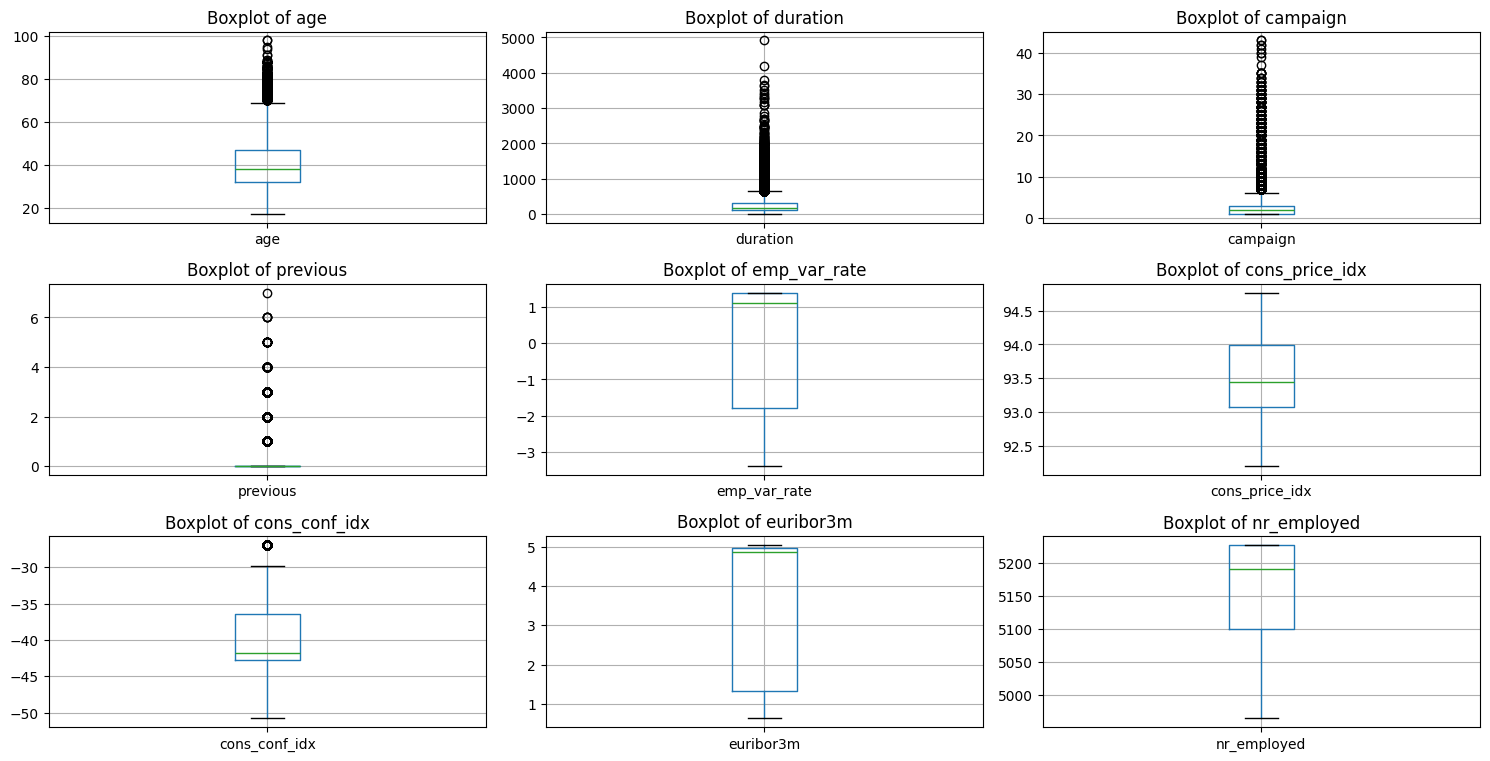

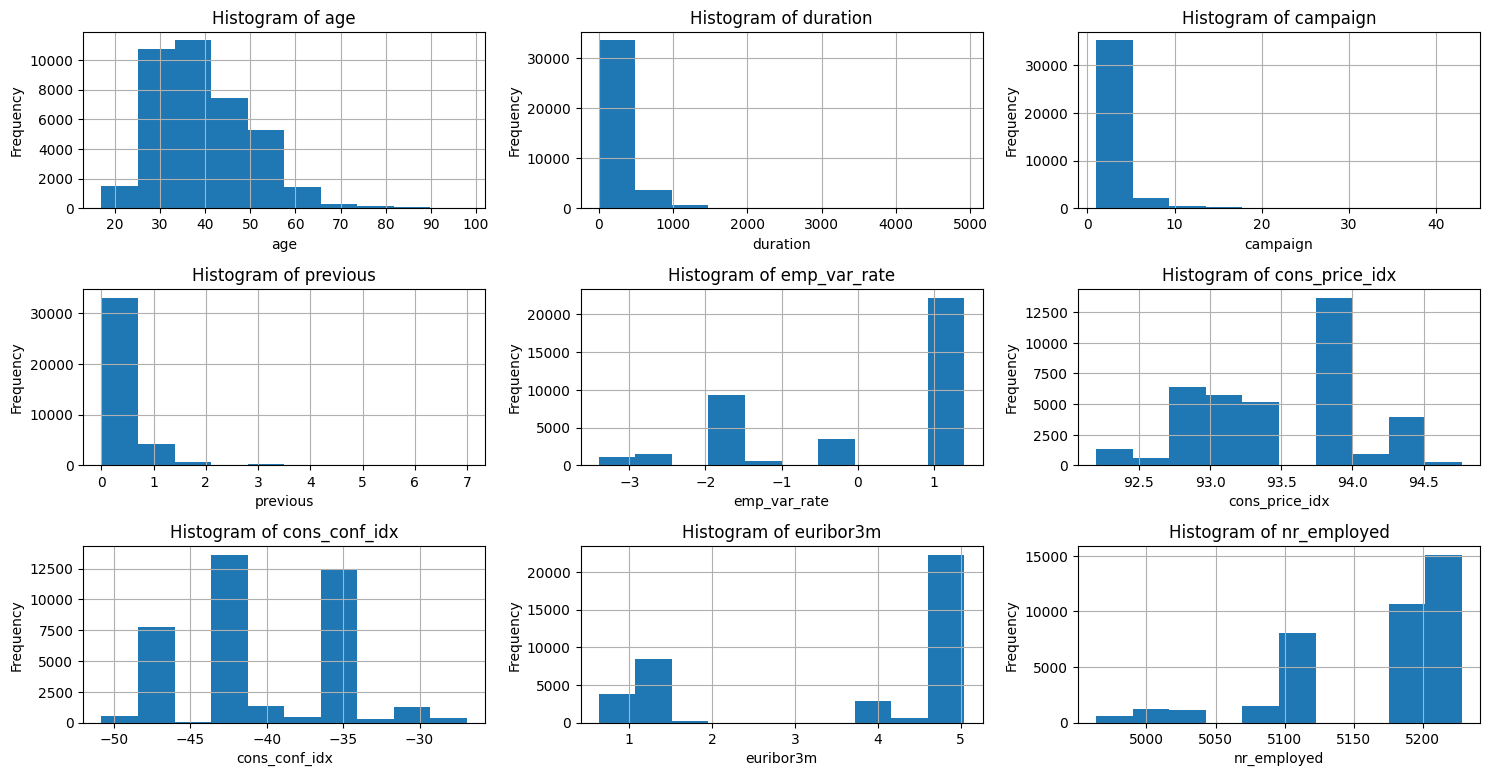

In [6]:
# Select numerical columns for boxplots and histograms (excluding the target and sex variables)
numerical_cols = ['age','duration','campaign','previous','emp_var_rate','cons_price_idx','cons_conf_idx',
                  'euribor3m','nr_employed']


# Create boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Create histogram for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    df[col].hist() # Use pandas hist method
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

Key Takeaways:
* `previous` exhibits discrete characteristics, with most values of zeroes. Instead of converting them to categorical variables with 'yes' or 'no' indicating if they were previously contacted, I think I will just remove this feature completely, given that `poutcome` already implicitly indicates if this client has previously been contacted.

* `age`, `duration`, and `campaign` are right-skewed, so I will do a log transform on these features.

* after all the above are done, I will then do a standardization transformation on all eight remaining numerical features.

In [7]:
from sklearn.preprocessing import StandardScaler

# Remove `previous` variable
df = df.drop('previous', axis = 1)

# log transform `age`, `duration`, `campaign`
# Add a small constant 0 to avoid log(0) if 0 values exist
df['age'] = np.log1p(df['age'])
df['duration'] = np.log1p(df['duration'])
df['campaign'] = np.log1p(df['campaign'])

# Standardizing numerical features
numerical_cols = ['age','duration','campaign','emp_var_rate','cons_price_idx','cons_conf_idx',
                  'euribor3m','nr_employed']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical Features after log transform and standardization:")
display(df[numerical_cols].head())

Numerical Features after log transform and standardization:


,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
0,1.485168,0.431743,-0.867095,0.649546,0.735109,0.895747,0.713039,0.328423
1,1.556298,-0.175585,-0.867095,0.649546,0.735109,0.895747,0.713039,0.328423
2,-0.173127,0.275591,-0.867095,0.649546,0.735109,0.895747,0.713039,0.328423
3,0.137645,-0.161161,-0.867095,0.649546,0.735109,0.895747,0.713039,0.328423
4,1.485168,0.607890,-0.867095,0.649546,0.735109,0.895747,0.713039,0.328423


## Train/Test Split (Stratified)

### Splitting Features and Target Variable

In [8]:
# Separate features (X) and target variable (y)
X = df.drop('y', axis=1)
y = df['y']

print("Features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)

Features (X) shape: (38245, 18)
Target variable (y) shape: (38245,)


### Splitting Data into train / validation/ test sets

train/val/test set split by 70/15/15

In [9]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26771, 18)
X_val shape: (5737, 18)
X_test shape: (5737, 18)
y_train shape: (26771,)
y_val shape: (5737,)
y_test shape: (5737,)


### Mode Imputation on `default` feature (Handling Missing Data: mode imputation is only done on train set)



In [10]:
# Calculate the mode for `default` for each `job` group
default_modes = X_train.groupby('job')['default'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Impute missing values based on the calculated modes for each group
X_train['default'] = df.apply(lambda row: default_modes[row['job']] if pd.isna(row['default']) else row['default'], axis=1)

## One-Hot Encoding

In [11]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Categorical columns (ensure these are the columns you want to encode in X_train, X_val, X_test)
categorical_cols = ['job','marital_status','education','default','housing','loan','contact','month','day_of_week','poutcome']

# Select numerical columns (assuming these are the ones left after dropping 'pdays' and 'previous' and before encoding)
# You should verify this list based on your previous steps
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]


ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit the encoder on the training data's categorical columns
ohe.fit(X_train[categorical_cols])

# Transform the categorical columns for each set
categorical_encoded_train = ohe.transform(X_train[categorical_cols])
categorical_encoded_val = ohe.transform(X_val[categorical_cols])
categorical_encoded_test = ohe.transform(X_test[categorical_cols])

# Create DataFrames from the encoded data with appropriate column names and preserve the original index
encoded_df_train = pd.DataFrame(categorical_encoded_train, columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
encoded_df_val = pd.DataFrame(categorical_encoded_val, columns=ohe.get_feature_names_out(categorical_cols), index=X_val.index)
encoded_df_test = pd.DataFrame(categorical_encoded_test, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)


# Drop original categorical columns from X_train, X_val, X_test
X_train = X_train.drop(categorical_cols, axis=1)
X_val = X_val.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)


# Concatenate the one-hot encoded DataFrames with the numerical features for each set
# Ensure the index is aligned during concatenation
X_train = pd.concat([X_train, encoded_df_train], axis=1)
X_val = pd.concat([X_val, encoded_df_val], axis=1)
X_test = pd.concat([X_test, encoded_df_test], axis=1)


print("X_train after one-hot encoding:")
display(X_train.head())
print("\nX_val after one-hot encoding:")
display(X_val.head())
print("\nX_test after one-hot encoding:")
display(X_test.head())

X_train after one-hot encoding:


,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_admin.,job_blue-collar,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
23133,-0.066891,-0.661578,-0.867095,0.841126,-0.219157,0.960638,0.775459,0.845428,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27112,0.332437,1.139852,0.544463,-0.116775,-0.642504,-0.315551,0.229858,0.395313,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8866,-1.278576,1.154932,-0.041386,0.841126,1.552308,-0.272290,0.718240,0.845428,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8878,1.264041,-0.523279,-0.867095,0.841126,1.552308,-0.272290,0.718240,0.845428,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6402,-1.570833,-0.205019,-0.041386,0.649546,0.735109,0.895747,0.713039,0.328423,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



X_val after one-hot encoding:


,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_admin.,job_blue-collar,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
35326,1.030271,-2.425610,1.684092,-1.202396,-1.175158,-1.224024,-1.371688,-0.952246,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24229,1.109688,-0.833231,-0.867095,-0.116775,-0.642504,-0.315551,0.328113,0.395313,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
12561,0.696219,-1.561806,-0.867095,0.841126,0.603247,-0.466963,0.772569,0.845428,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
24662,0.696219,0.696141,-0.041386,-0.116775,-0.642504,-0.315551,0.328113,0.395313,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
9194,0.036655,-0.235270,0.544463,0.841126,1.552308,-0.272290,0.776615,0.845428,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



X_test after one-hot encoding:


,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_admin.,job_blue-collar,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
31918,-0.628024,1.299005,-0.041386,-1.202396,-1.175158,-1.224024,-1.327184,-0.952246,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1604,-1.005818,0.813481,-0.867095,0.649546,0.735109,0.895747,0.711883,0.328423,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16208,0.518371,-0.696152,-0.867095,0.841126,0.603247,-0.466963,0.773147,0.845428,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
23021,1.485168,1.091051,0.998884,0.841126,-0.219157,0.960638,0.775459,0.845428,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31520,-0.875970,1.643233,-0.041386,-1.202396,-1.175158,-1.224024,-1.323138,-0.952246,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Target Variable Class Distribution

To understand target variable class distribution, to determine suitable metrics to evaluate models.

In [12]:
# Calculate the class distribution of the target variable
target_distribution = df['y'].value_counts()
total_instances = target_distribution.sum()
target_percentage = (target_distribution / total_instances) * 100

# Create a DataFrame to display counts and percentages side by side
target_summary = pd.DataFrame({
    'Count': target_distribution,
    'Percentage (%)': round(target_percentage,2)
})

print("Class distribution of the target variable:")
display(target_summary)

Class distribution of the target variable:


,Count,Percentage (%)
y,,
no,33987,88.87
yes,4258,11.13


Target distribution shows that it is imbalanced, hence we will use metrics such as Precision, Recall, and F1 to evaluate our models, instead of using Accuracy.

## Target Variable Encoder

In [13]:
y_train = y_train.map({'yes': 1, 'no': 0})
y_val = y_val.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})

# Baseline Model: Decision Tree

## Train a DecisionTreeClassifier using Gini impurity

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)


for max_depth in [3, 5, 7, 10, None]:
  for min_samples_split in [2, 5, 10]:
    for ccp_alpha in [0.0, 0.01, 0.001]:
      model = DecisionTreeClassifier(
          max_depth = max_depth,
          min_samples_split = min_samples_split,
          ccp_alpha = ccp_alpha,
          random_state = 42
      )
      model.fit(X_train, y_train)
      y_pred = model.predict(X_val)
      val_score = f1_score(y_val, y_pred) # Calculate F1-score
      print(f"{max_depth=}, {min_samples_split=}, {ccp_alpha=}, val_f1={val_score:.3f}") # Print F1-score

max_depth=3, min_samples_split=2, ccp_alpha=0.0, val_f1=0.573
max_depth=3, min_samples_split=2, ccp_alpha=0.01, val_f1=0.478
max_depth=3, min_samples_split=2, ccp_alpha=0.001, val_f1=0.573
max_depth=3, min_samples_split=5, ccp_alpha=0.0, val_f1=0.573
max_depth=3, min_samples_split=5, ccp_alpha=0.01, val_f1=0.478
max_depth=3, min_samples_split=5, ccp_alpha=0.001, val_f1=0.573
max_depth=3, min_samples_split=10, ccp_alpha=0.0, val_f1=0.573
max_depth=3, min_samples_split=10, ccp_alpha=0.01, val_f1=0.478
max_depth=3, min_samples_split=10, ccp_alpha=0.001, val_f1=0.573
max_depth=5, min_samples_split=2, ccp_alpha=0.0, val_f1=0.604
max_depth=5, min_samples_split=2, ccp_alpha=0.01, val_f1=0.478
max_depth=5, min_samples_split=2, ccp_alpha=0.001, val_f1=0.603
max_depth=5, min_samples_split=5, ccp_alpha=0.0, val_f1=0.604
max_depth=5, min_samples_split=5, ccp_alpha=0.01, val_f1=0.478
max_depth=5, min_samples_split=5, ccp_alpha=0.001, val_f1=0.603
max_depth=5, min_samples_split=10, ccp_alpha=0.0, va

Out of all the options, we pick the option which produces the highest F1-score, which is 0.607. Since there are more than one combination of parameters that produces this value, I will pick the one that produces F1-score of 0.607, the smallest max_depth value, the highest min_samples_split value, and the highest value of ccp_alpha. All of this is so that we select parameters that result in the simplest model to reduce overfitting.

For this reason, I will move forward with max_depth of 7, min_samples_split of 10, and ccp_alpha of 0.001.

## Plot the learning curve to show how training and validation scores change with depth

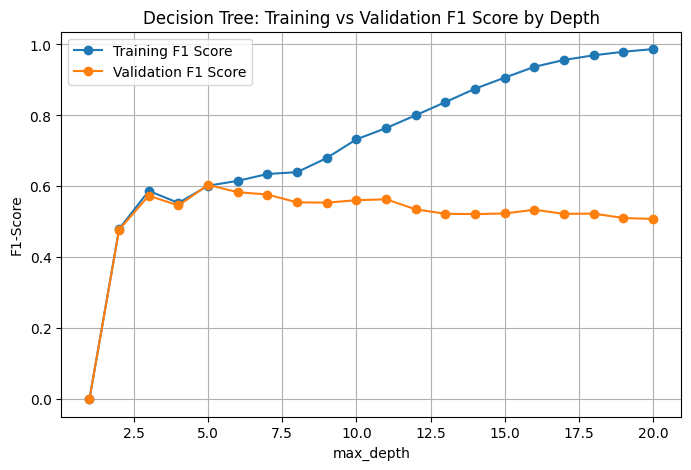

In [15]:
# Arrays to store results
depths = range(1, 21)  # test depths 1 to 20
train_scores = []
val_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    # predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # compute accuracy (can replace with F1 or other metrics)
    train_acc = f1_score(y_train, y_train_pred)
    val_acc = f1_score(y_val, y_val_pred)

    train_scores.append(train_acc)
    val_scores.append(val_acc)

# Plot the learning curve
plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker='o', label='Training F1 Score')
plt.plot(depths, val_scores, marker='o', label='Validation F1 Score')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.title('Decision Tree: Training vs Validation F1 Score by Depth')
plt.legend()
plt.grid(True)
plt.show()

From the plot above, we can see that the optimal depth on both training and validation set is 5. After depth of 5, we can see that training F1 continues to increase while validation F1 score starts to decrease. This separation indicates that the model starts to overfit at these depths, we see that the model starts to overfit on the training data, and prediction power on the validation set starts to decrease.

In [16]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split = 10, ccp_alpha = 0.001)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
test_score = f1_score(y_val, y_pred)
print(f"Validation F1 Score:{test_score:.3f}")

Validation F1 Score:0.603


# Boosting Methods

Compare baseline: Random Forest with three boosting methods

### GridSearchCV  to optimize hyperparameters

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('xgb', XGBClassifier(random_state=42))
]

# Define parameter grids for each estimator
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

param_grids = {
    'rf': param_grid_rf,
    'gb': param_grid_gb,
    'xgb': param_grid_xgb
}

best_models = {}

for name, estimator in estimators:
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(estimator=estimator, param_grid=param_grids[name],
                               scoring='f1', cv=3, n_jobs=-1) # Using F1-score for evaluation
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best F1-score for {name}: {grid_search.best_score_:.3f}")
    print("-" * 30)

Running GridSearchCV for rf...
Best parameters for rf: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best F1-score for rf: 0.524
------------------------------
Running GridSearchCV for gb...
Best parameters for gb: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best F1-score for gb: 0.580
------------------------------
Running GridSearchCV for xgb...
Best parameters for xgb: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best F1-score for xgb: 0.583
------------------------------


By using GridSearchCV, we are able to tune the hyperparameters to get the best results for each of our models. I will use these hyperparameters to run my models.

## Baseline: Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 300, random_state = 42, min_samples_split=2, ccp_alpha=0.00)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
test_score = f1_score(y_val, y_pred)
print(f"Validation F-1 Score: {test_score:.3f}")

Validation F-1 Score: 0.556


## Gradient Boosting

Train a **GradientBoostingClassifier** using scikit-learn. Explore how the following parameters affect performance and overfitting: `learning_rate`, `n_estimators`, `max_depth`, `subsample`.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,
                                   max_depth=3, random_state=42, subsample=0.8)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
test_score = f1_score(y_val, y_pred)
print(f"Validation F-1 Score: {test_score:.3f}")

Validation F-1 Score: 0.586


## XGBoost

Install and use **XGBoostClassifier** (xgboost library). Perform similar tuning and visualize:
* training vs validation loss (using `eval_set` or early stopping)
* feature importance (`plot_importance`)
* effect of learning rate and tree depth on bias-variance balance

[0]	validation_0-logloss:0.31082	validation_1-logloss:0.31129
[1]	validation_0-logloss:0.28689	validation_1-logloss:0.28733
[2]	validation_0-logloss:0.26904	validation_1-logloss:0.26914
[3]	validation_0-logloss:0.25504	validation_1-logloss:0.25525
[4]	validation_0-logloss:0.24350	validation_1-logloss:0.24399
[5]	validation_0-logloss:0.23388	validation_1-logloss:0.23443
[6]	validation_0-logloss:0.22573	validation_1-logloss:0.22663
[7]	validation_0-logloss:0.21852	validation_1-logloss:0.21949
[8]	validation_0-logloss:0.21236	validation_1-logloss:0.21350
[9]	validation_0-logloss:0.20707	validation_1-logloss:0.20853
[10]	validation_0-logloss:0.20263	validation_1-logloss:0.20429
[11]	validation_0-logloss:0.19887	validation_1-logloss:0.20075
[12]	validation_0-logloss:0.19518	validation_1-logloss:0.19744
[13]	validation_0-logloss:0.19202	validation_1-logloss:0.19443
[14]	validation_0-logloss:0.18921	validation_1-logloss:0.19170
[15]	validation_0-logloss:0.18662	validation_1-logloss:0.18945
[1

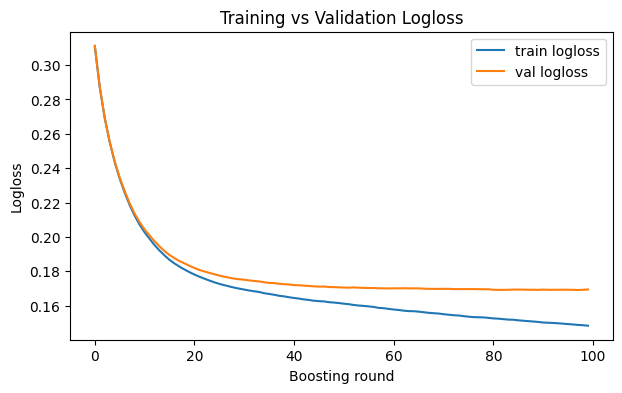

Test AUC after training with 100 estimators: 0.952


In [20]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                          subsample=0.8, eval_metric='logloss')

# Train the model without early stopping
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])

res = model.evals_result()
train_ll = res["validation_0"]["logloss"]
val_ll = res["validation_1"]["logloss"]

plt.figure(figsize=(7,4))
plt.plot(train_ll, label="train logloss")
plt.plot(val_ll, label="val logloss")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.title("Training vs Validation Logloss")
plt.legend()
plt.show()

# Note: best_iteration and AUC at best_iter are not available without early stopping
# We can still evaluate on the test set after training with 100 estimators
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print(f"Test AUC after training with {model.n_estimators} estimators: {test_auc:.3f}")

### Feature Importance (plot_importance())

<Figure size 800x600 with 0 Axes>

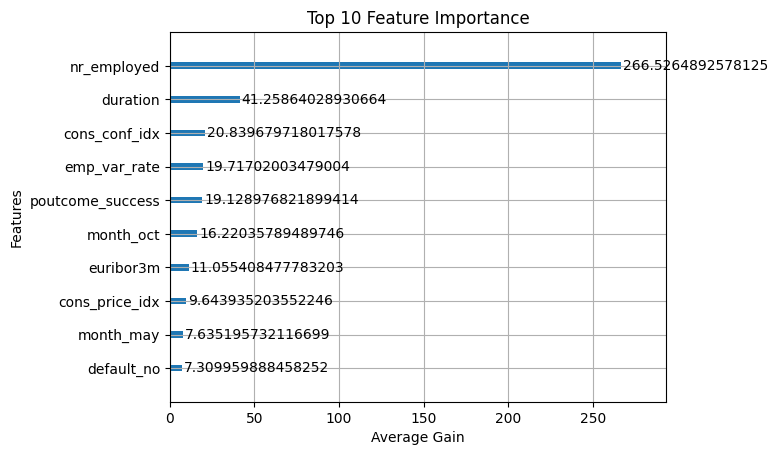

In [21]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(model, max_num_features=10, importance_type='gain', xlabel='Average Gain')
plt.title("Top 10 Feature Importance")
plt.show()

The feature importance plot shows which features have the highest predictive power. It does it by showing how much the feature improves the model's performance by reducing logloss on average across all splits where it appears. Based on the plot, `nr_employed` is the most important feature in predicting whether a customer will subscribe to a term deposit in the XGBoost model.

## LightGBM

Implement **LightGBM** and compare their speed and accuracy against XGBoost. Discuss how different boosting frameworks handle categorical features and regularization.

In [38]:
import lightgbm as lgb
import time
from sklearn.metrics import log_loss, roc_auc_score

model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.01, max_depth=6, subsample=0.8, random_state=42)

t0 = time.time()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)],
          eval_metric="logloss")

lgbm_time = time.time() - t0

lgbm_metrics = {
    "best_iter": model.best_iteration_,
    "train_logloss": log_loss(y_train, model.predict_proba(X_train)[:,1]),
    "val_logloss": log_loss(y_val, model.predict_proba(X_val)[:,1]),
    "val_auc": roc_auc_score(y_val, model.predict_proba(X_test)[:,1]),
    "fit_time_s": lgbm_time
}

lgbm_metrics

[LightGBM] [Info] Number of positive: 2981, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 26771, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111352 -> initscore=-2.077007
[LightGBM] [Info] Start training from score -2.077007


{'best_iter': 0,
 'train_logloss': 0.20707483441951535,
 'val_logloss': 0.20904016442930357,
 'val_auc': np.float64(0.5090590621011277),
 'fit_time_s': 0.2680361270904541}

LightGBM vs XGBoost
* Handling Categorical Features
    * LightGBM: LightGBM offers native support for categorical features, which means it can handle integer-encoded categorical features, thus there is no need to undergo one-hot encoding when using this model. It is better for high cardinality data.
    * XGBoost: XGBoost requires manual preprocessing of categorical features, typically through one-hot encoding or target label encoding.
* Regularization
    * LightGBM: LightGBM does the same regularization as XGBoost, but it has additional techniques "Gradient-based One-Side Sampling" and "Exclusive Feature Bundling", which can be seen as regularization and speed optimization.
    * XGBoost: XGBoost uses L1 (Lasso) and L2 (ridge) regularization to control the weight of the leaves, in order to control model complexity and prevent overfitting.

# Model Evaluation and Visualization

## Model Evaluation



Evaluating rf on the test set...
--- rf Evaluation ---
Accuracy: 0.914
Precision: 0.656
Recall: 0.475
F1-Score: 0.551
AUCPR: 0.658
------------------------------


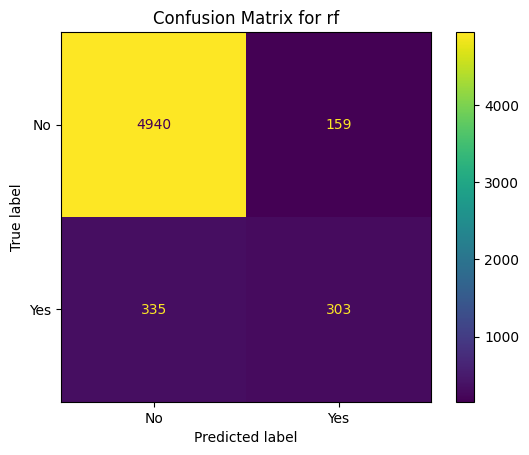

Evaluating gb on the test set...
--- gb Evaluation ---
Accuracy: 0.920
Precision: 0.667
Recall: 0.558
F1-Score: 0.608
AUCPR: 0.665
------------------------------


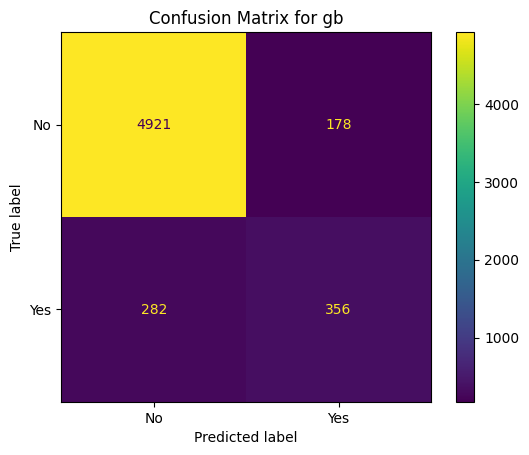

Evaluating xgb on the test set...
--- xgb Evaluation ---
Accuracy: 0.924
Precision: 0.684
Recall: 0.583
F1-Score: 0.629
AUCPR: 0.691
------------------------------


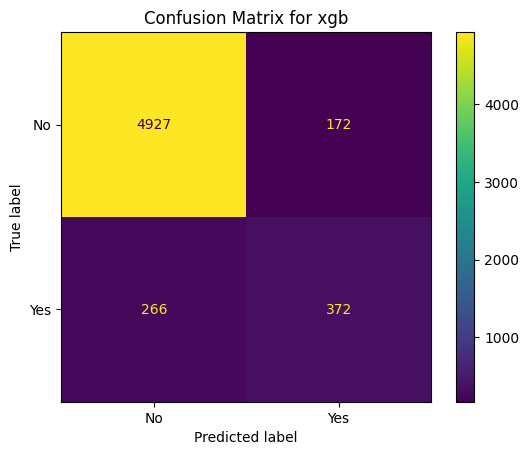

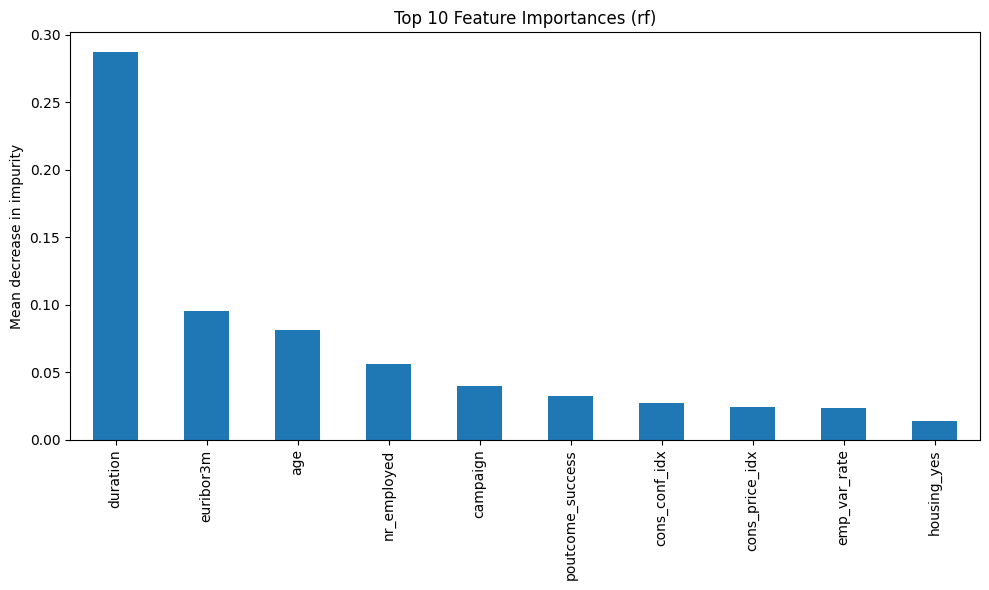

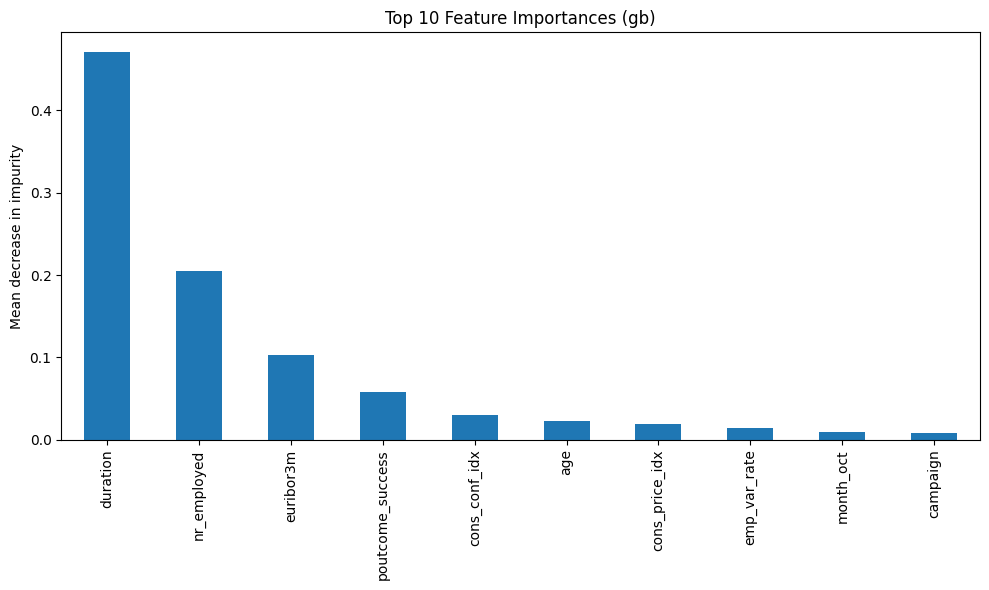

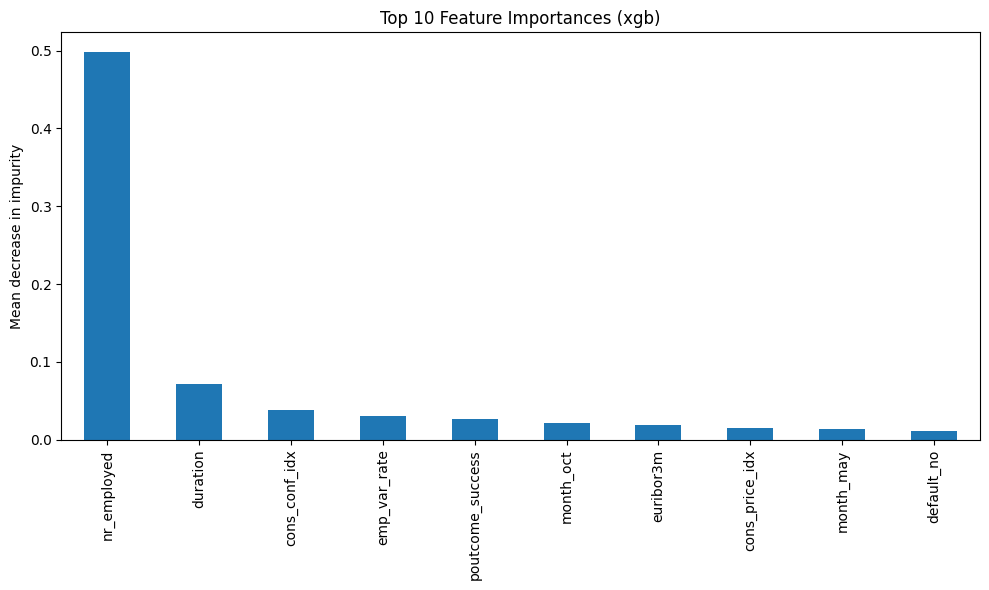

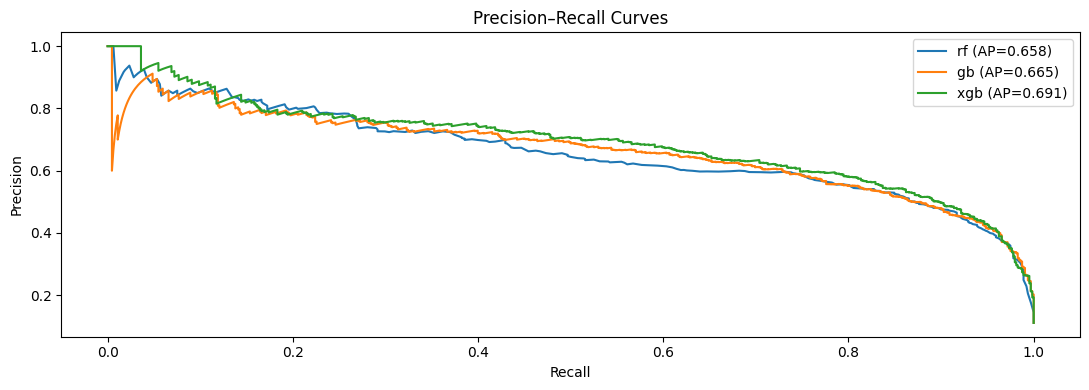

In [30]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    average_precision_score, roc_auc_score, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from xgboost.plotting import plot_importance

# Evaluate best models on the test set
evaluation_results = {}
probas = {} # Store probabilities for ROC and PR curves

for name, model in best_models.items():
    print(f"Evaluating {name} on the test set...")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    probas[name] = y_proba # Store probabilities

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_proba)


    evaluation_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUCPR': auc_pr,
    }

    print(f"--- {name} Evaluation ---")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"AUCPR: {auc_pr:.3f}")
    print("-" * 30)

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot()
    plt.title(f'Confusion Matrix for {name}')
    plt.show()


# Plot feature importance for tree-based models (Random Forest, Gradient Boosting, XGBoost)
for name in ['rf', 'gb', 'xgb']:
    if name in best_models and hasattr(best_models[name], 'feature_importances_'):
        model = best_models[name]
        importances = model.feature_importances_
        feature_names = X_test.columns
        forest_importances = pd.Series(importances, index=feature_names)

        fig, ax = plt.subplots(figsize=(10, 6))
        forest_importances.sort_values(ascending=False)[:10].plot.bar(ax=ax)
        ax.set_title(f"Top 10 Feature Importances ({name})")
        ax.set_ylabel("Mean decrease in impurity")
        plt.tight_layout()
        plt.show()
    elif name in best_models and hasattr(best_models[name], 'get_booster'): # For XGBoost
         model = best_models[name]
         plot_importance(model, max_num_features=10, importance_type='gain', xlabel='Average Gain', title=f'Top 10 Feature Importance ({name})')
         plt.show()



# Plot PR curve for imbalanced data
plt.figure(figsize=(11,4))
for name, y_proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()

plt.tight_layout()
plt.show()

# Summary of Results

Based on the evaluation metrics on the test set, here is a summary of the model performance:

| Model              | Accuracy | Precision | Recall | F1-Score | AUCPR |
|--------------------|----------|-----------|--------|----------|-------|
| Random Forest      | 0.914    | 0.656     | 0.475  | 0.551    | 0.658 |
| Gradient Boosting  | 0.920    | 0.667     | 0.558  | 0.608    | 0.665 |
| XGBoost            | 0.924    | 0.684     | 0.583  | 0.629    | 0.691 |

From the table and the plots, we can observe the following:

*   **Overall Performance:** All the models show good overall accuracy, but due to the class imbalance, F1-score and AUCPR should be used to evaluate metrics. XGBoost performs the best across these metrics.

*   **Boosting vs. Bagging:** Both Gradient Boosting and XGBoost outperform the Random Forest (Bagging) model, which is expected as boosting methods typically yield higher accuracy by sequentially correcting the errors of previous trees. This iterative process reduces bias by gradually improving the model's fit to the data.

*   **Precision and Recall:** XGBoost achieves the highest precision and recall among the three models, suggesting it is a better model at identifying positive cases (clients who subscribe to a term deposit) while maintaining a relatively low rate of false positives.
*   **AUCPR:** The higher AUCPR and AUROC scores for XGBoost further confirm its superior performance, especially in handling the imbalanced dataset.

*   **Feature Importance Plot:** The feature importance plots show that `nr_employed` is a consistently important feature across the tree-based models, highlighting its strong influence on the prediction of term deposit subscriptions. This plot is important as it lets us know which features are strong indicators for our target, hence we can focus on these features in marketing campaigns and strategy.

*   **Bias-Variance Tradeoff:** Results show that boosting models outperformed the single Decision Tree and the Random Forest (bagging) model. The Decision Tree combined with limited depth might have high bias (thus result in underfitting) if it's too simple to capture the complex relationships in the data. While Random Forest can reduce variance by averaging predictions, it can still suffer from high variance if individual trees are deep and overfit. Boosting models iteratively improves by focusing on errors, and are effective at reducing both bias and variance, leading to a higher performance on the test set.

*   **Number of Estimators Affect Boosting:** Increasing the number of estimators (trees) in boosting models reduces bias. Each new tree focuses on errors made by the ensemble of previous trees, allowing the model to capture more complex patterns in the data. However, a downside to this is it will cause the model to overfit, where the model captures patterns in the training data too closely and perform poorly and weak generalization on unseen data.

*   **Downsides of Boosting Model:** Although boosting models yield the best results, however it is more computationally expensive as compared to decision trees. Besides that, boosting models are also more complex than a simple decision tree, where it is more challenging and difficult to interpret and explain boosting models.



# AI Tool Disclosure

Chatgpt was used:
* to build the starter code for LightGBM.
* to build the starter code for Model Evaluation.
* to understand the difference between XGBoost and LightGBM.